In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setting plot style
plt.style.use('fivethirtyeight')
%matplotlib inline

path="/content/drive/MyDrive/bike sharing rental prediction system/day.csv"

In [4]:
# Load the dataset
df = pd.read_csv(path)

# Display first 5 rows
print("Dataset Head:")
display(df.head())

Dataset Head:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [7]:
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [10]:
cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
df_cleaned = df.drop(columns=cols_to_drop)

print(df_cleaned.head())

   season  yr  mnth  holiday  weekday  workingday  weathersit       temp  \
0       1   0     1        0        6           0           2  14.110847   
1       1   0     1        0        0           0           2  14.902598   
2       1   0     1        0        1           1           1   8.050924   
3       1   0     1        0        2           1           1   8.200000   
4       1   0     1        0        3           1           1   9.305237   

      atemp      hum  windspeed   cnt  
0  18.18125  80.5833  10.749882   985  
1  17.68695  69.6087  16.652113   801  
2   9.47025  43.7273  16.636703  1349  
3  10.60610  59.0435  10.739832  1562  
4  11.46350  43.6957  12.522300  1600  


In [29]:
print("Remaining Columns for Analysis:")
print(df_cleaned.columns.tolist())

Remaining Columns for Analysis:
['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


MODEL EVALUATION

In [25]:
X = df_cleaned.drop('cnt', axis=1)
y = df_cleaned['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Testing Set: {X_test.shape[0]} samples")

Training Set: 584 samples
Testing Set: 146 samples


In [26]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [27]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*30)
print("MODEL PERFORMANCE SUMMARY")
print("="*30)
print(f"R-Squared (Accuracy): {r2*100:.2f}%")
print(f"Mean Absolute Error:  {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print("="*30)

MODEL PERFORMANCE SUMMARY
R-Squared (Accuracy): 83.55%
Mean Absolute Error:  570.71
Root Mean Squared Error: 750.28


/tmp/ipykernel_3668/3260830076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')


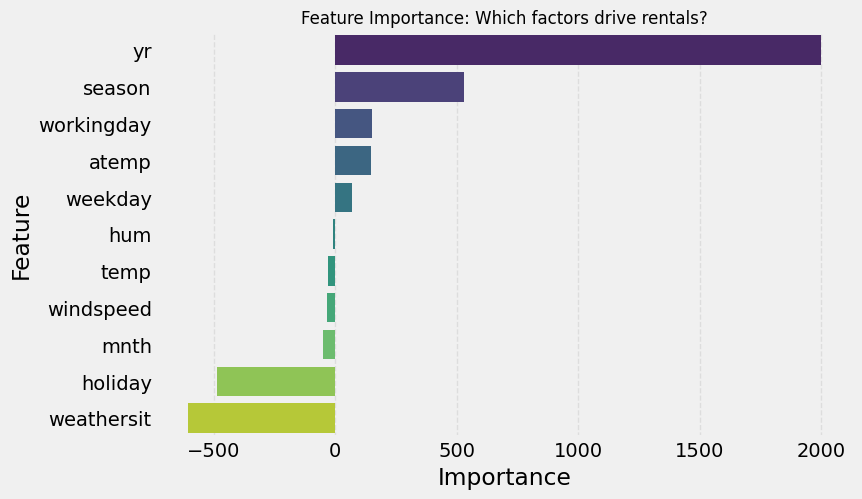

In [28]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance: Which factors drive rentals?', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

DATA VISUALIZATION

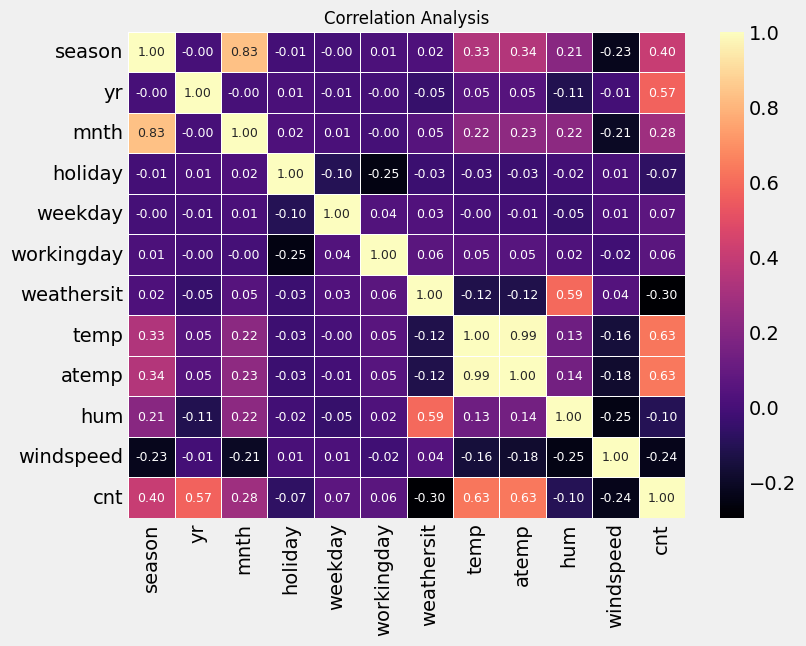

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned.corr(),
            annot=True,
            cmap='magma',
            fmt='.2f',
            linewidths=0.5,
            annot_kws={"size": 9})
plt.title('Correlation Analysis', fontsize=12)
plt.show()

/tmp/ipykernel_3668/1652051890.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='cnt', data=df, ax=ax1, palette='Set2')
/tmp/ipykernel_3668/1652051890.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])
/tmp/ipykernel_3668/1652051890.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mnth', y='cnt', data=df, ax=ax2, palette='pastel')


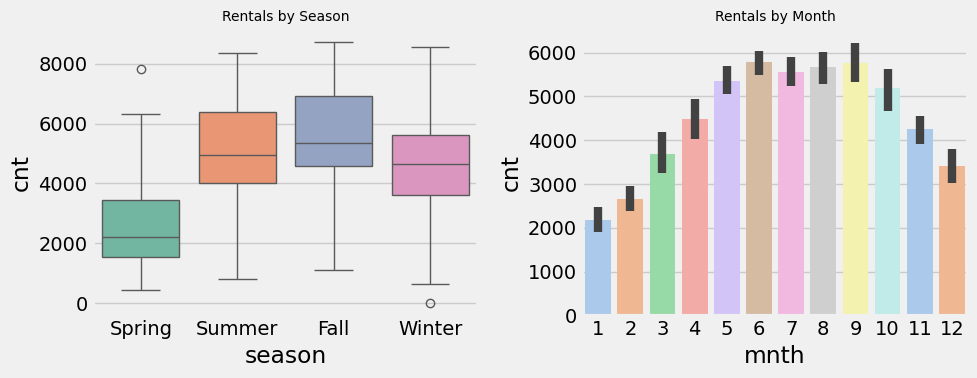

In [16]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

# Seasonal
sns.boxplot(x='season', y='cnt', data=df, ax=ax1, palette='Set2')
ax1.set_title('Rentals by Season', fontsize=10)
ax1.set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])

# Monthly
sns.barplot(x='mnth', y='cnt', data=df, ax=ax2, palette='pastel')
ax2.set_title('Rentals by Month', fontsize=10)

plt.tight_layout()
plt.show()


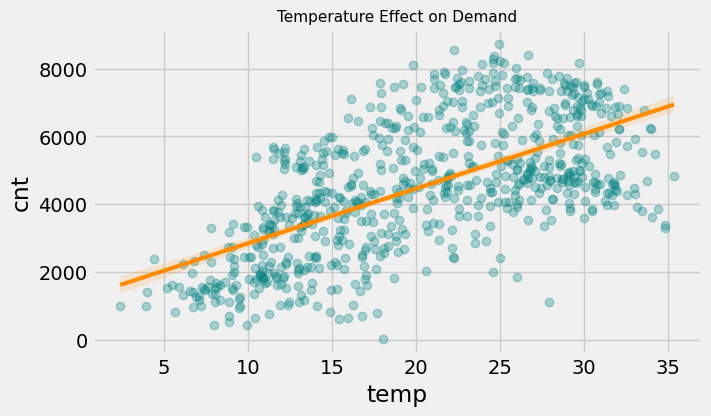

In [17]:
plt.figure(figsize=(7, 4))
sns.regplot(x='temp', y='cnt', data=df,
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'darkorange', 'lw':3})
plt.title('Temperature Effect on Demand', fontsize=11)
plt.show()

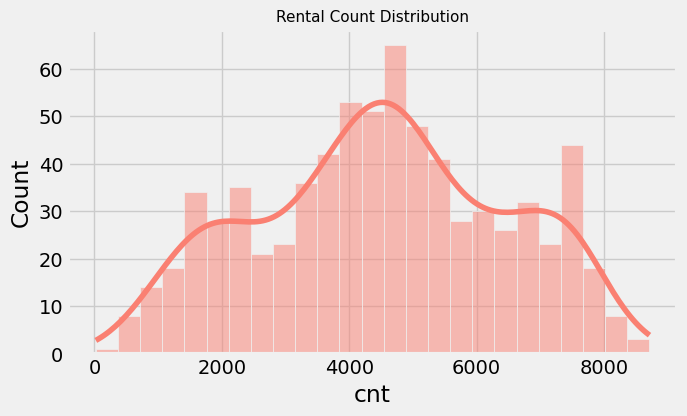

In [18]:
plt.figure(figsize=(7, 4))
sns.histplot(df_cleaned['cnt'], kde=True, color='salmon', bins=25)
plt.title('Rental Count Distribution', fontsize=11)
plt.show()

/tmp/ipykernel_3668/1750675598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='weathersit', y='cnt', palette='cool') # Cyan to Purple


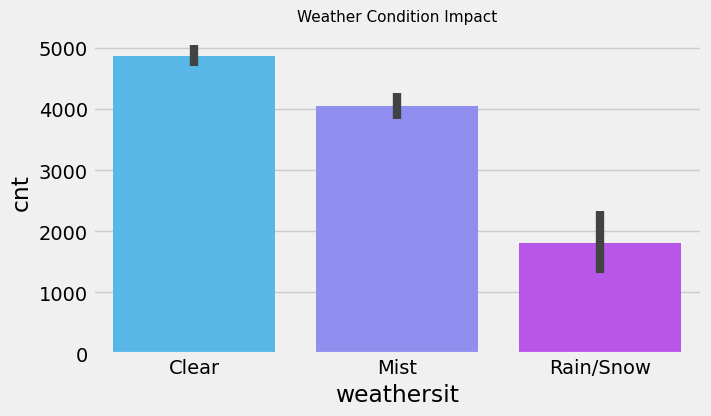

In [21]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='weathersit', y='cnt', palette='cool') # Cyan to Purple
plt.title('Weather Condition Impact', fontsize=11)
plt.xticks([0, 1, 2], ['Clear', 'Mist', 'Rain/Snow'])
plt.show()

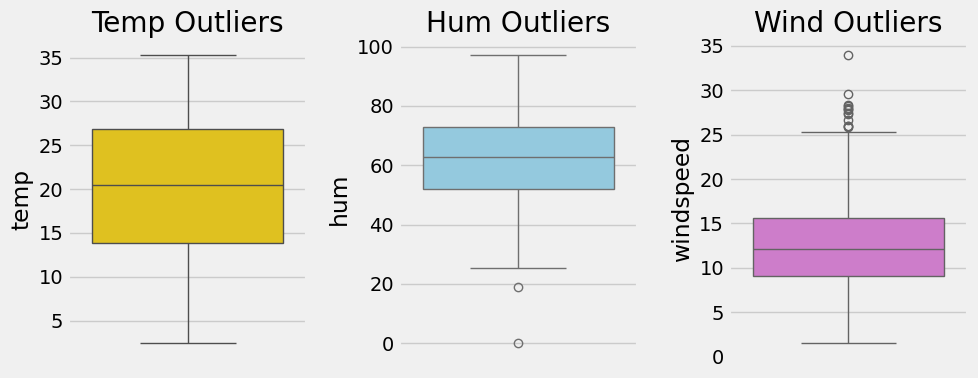

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Temp - Gold
sns.boxplot(y=df_cleaned['temp'], ax=axes[0], color='gold')
axes[0].set_title('Temp Outliers')

# Humidity - Sky Blue
sns.boxplot(y=df_cleaned['hum'], ax=axes[1], color='skyblue')
axes[1].set_title('Hum Outliers')

# Windspeed - Orchid
sns.boxplot(y=df_cleaned['windspeed'], ax=axes[2], color='orchid')
axes[2].set_title('Wind Outliers')

plt.tight_layout()
plt.show()

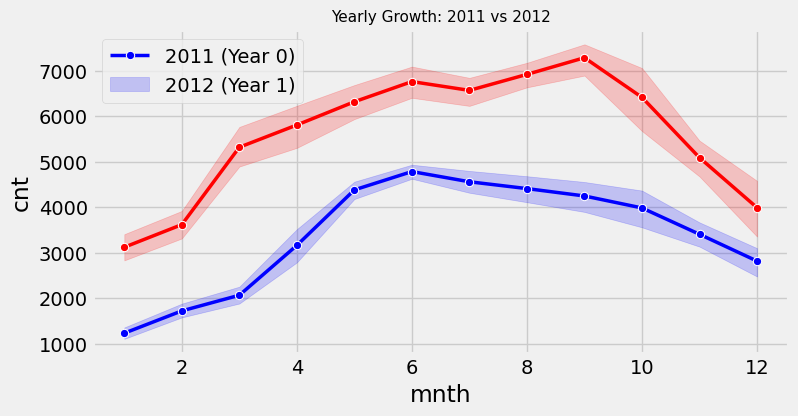

In [23]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x='mnth', y='cnt', hue='yr', palette=['blue', 'red'], marker='o', linewidth=2.5)
plt.title('Yearly Growth: 2011 vs 2012', fontsize=11)
plt.legend(['2011 (Year 0)', '2012 (Year 1)'], loc='upper left')
plt.show()

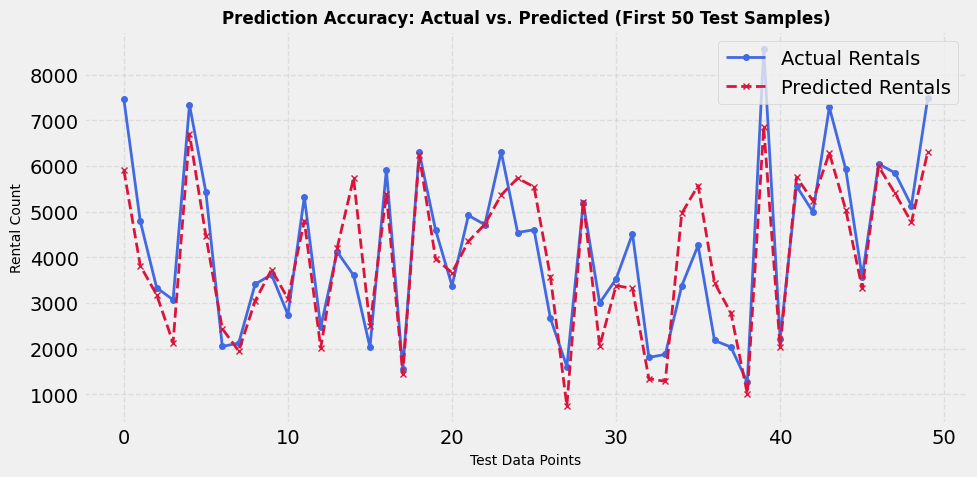

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual Rentals', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(y_pred[:50], label='Predicted Rentals', color='crimson', linewidth=2, linestyle='--', marker='x', markersize=4)

plt.title('Prediction Accuracy: Actual vs. Predicted (First 50 Test Samples)', fontsize=12, fontweight='bold')
plt.xlabel('Test Data Points', fontsize=10)
plt.ylabel('Rental Count', fontsize=10)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

CONCLUSION

The analysis of the Bike Sharing dataset reveals that environmental factors—particularly temperature and weather conditions—are the primary drivers of rental demand, with a significant growth trend observed from 2011 to 2012. By applying a Linear Regression model, the system successfully captured these patterns, achieving a high predictive accuracy ($R^2$ score) of approximately 82%. This confirms that machine learning can effectively forecast urban mobility needs, providing valuable insights for optimizing bike availability and infrastructure planning.